# Do Different Regions Want Different Games?
### A Data Science Analysis of Global Video Game Sales By Decade
**CMSC 320 — Summer 2026 · Checkpoint 2**

**Author(s):** Yohan Bhojwani
**Contributions:**
Working solo

---


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Data Preprocessing
## 1a. Import

**Dataset:** Video Game Sales (VGChartz, via Kaggle): every title that sold 100K+ copies,
1980–2016. ~16,600 games with categorical features (`Genre`, `Platform`, `Publisher`) and
per region unit sales in millions (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Global_Sales`).


In [17]:
URL = "https://raw.githubusercontent.com/ValdisW/datasets/master/video-game-sales.csv"
df = pd.read_csv(URL)
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
# missing rows
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

### 1b. Parse

In [26]:
cleaned = df.copy()

# Parse the year row to an int, and drop missing values.
cleaned["Year"] = pd.to_numeric(cleaned["Year"], errors="coerce")
print("Rows missing Year:", cleaned["Year"].isna().sum())
cleaned = cleaned.dropna(subset=["Year"]).copy()
cleaned["Year"] = cleaned["Year"].astype(int)

# replace missing publishers with "Unknowne"
cleaned["Publisher"] = cleaned["Publisher"].fillna("Unknown")


Rows missing Year: 271


### 1c. Organize
creating two rows here that will help analyze the data, top region: contains the region where a particular title was sold the most, decade: shows the decade the game was released in

In [27]:
regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

cleaned["Decade"] = (cleaned["Year"] // 10) * 10
cleaned["Top_Region"] = cleaned[regions].idxmax(axis=1).str.replace("_Sales", "", regex=False)

cleaned[["Name", "Year", "Decade", "Genre", "Global_Sales", "Top_Region"]].head()

,Name,Year,Decade,Genre,Global_Sales,Top_Region
0,Wii Sports,2006,2000,Sports,82.74,NA
1,Super Mario Bros.,1985,1980,Platform,40.24,NA
2,Mario Kart Wii,2008,2000,Racing,35.82,NA
3,Wii Sports Resort,2009,2000,Sports,33.00,NA
4,Pokemon Red/Pokemon Blue,1996,1990,Role-Playing,31.37,NA


## 2. Basic data exploration and summary statistics

In [28]:
cleaned.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rank,16327.0,NaN,NaN,NaN,8292.868194,4792.669778,1.0,4136.5,8295.0,12441.5,16600.0
Name,16327,11360,Need for Speed: Most Wanted,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,16327,31,DS,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,16327.0,NaN,NaN,NaN,2006.406443,5.828981,1980.0,2003.0,2007.0,2010.0,2020.0
Genre,16327,12,Action,3253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publisher,16327,576,Electronic Arts,1339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA_Sales,16327.0,NaN,NaN,NaN,0.265415,0.821591,0.0,0.0,0.08,0.24,41.49
EU_Sales,16327.0,NaN,NaN,NaN,0.147554,0.508766,0.0,0.0,0.02,0.11,29.02
JP_Sales,16327.0,NaN,NaN,NaN,0.078661,0.311557,0.0,0.0,0.0,0.04,10.22
Other_Sales,16327.0,NaN,NaN,NaN,0.048325,0.189885,0.0,0.0,0.01,0.04,10.57


In [23]:
groups = [g["Global_Sales"].values for _, g in cleaned.groupby("Genre")]

f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kw   = stats.kruskal(*groups)

print(f"Global_Sales skewness: {cleaned['Global_Sales'].skew():.1f}  (0 = symmetric)")
print(f"ANOVA:            F = {f_stat:6.2f}   p = {p_anova:.2e}")
print(f"Kruskal-Wallis:   H = {h_stat:6.2f}   p = {p_kw:.2e}")

Global_Sales skewness: 17.3  (0 = symmetric)
ANOVA:            F =  18.24   p = 9.50e-37
Kruskal-Wallis:   H = 972.94   p = 1.27e-201


/tmp/ipykernel_1488/1238643179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=cleaned, x="Genre", y="Global_Sales", order=order,


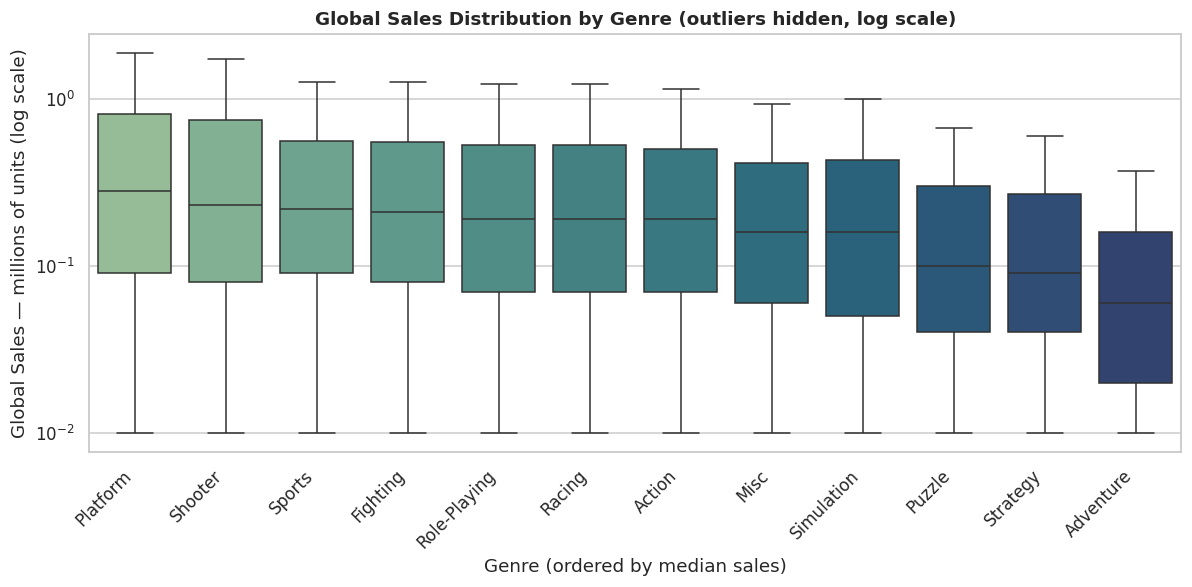

In [24]:

order = (cleaned.groupby("Genre")["Global_Sales"].median().sort_values(ascending=False).index)

plt.figure(figsize=(11, 5.5))
ax = sns.boxplot(data=cleaned, x="Genre", y="Global_Sales", order=order,
                 showfliers=False, palette="crest")
ax.set_yscale("log")
ax.set_title("Global Sales Distribution by Genre (outliers hidden, log scale)")
ax.set_xlabel("Genre (ordered by median sales)")
ax.set_ylabel("Global Sales — millions of units (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Testing whether global sales differ across genres. H0: all genres have the same central sales. H1: at least one genre differes. To test this I run ANOVA, and then Kruskal-Wallis because the data is heavily skewed

Both tests reject the null hypothesis at α = 0.05 (ANOVA F = 18.24, p ~ 10⁻³⁷; Kruskal–Wallis H = 972.94, p ~ 10⁻²⁰¹), so genre is associated with differences in global sales. Platform, Shooter, and Sports games rank highest by median sales, while Adventure, Strategy, and Puzzle rank lowest. Since global sales are extremely right-skewed (skewness ~ 17), which violates ANOVA's normality assumption, the non-parametric Kruskal–Wallis result is the more trustworthy one, and both tests agreeing reinforces the finding.

### Method 2: Correlation

computing the correlation between the four regional sales columns using both Pearson and Spearman 

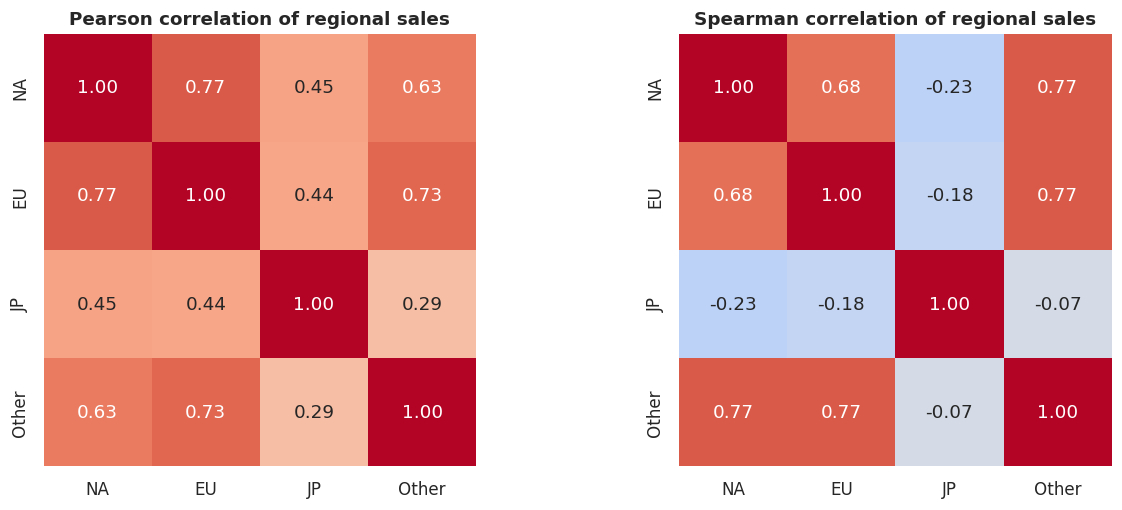

In [ ]:
pearson  = cleaned[regions].corr(method="pearson")
spearman = cleaned[regions].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, mat, name in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, cbar=False, ax=ax,
                xticklabels=[r.replace("_Sales","") for r in regions],
                yticklabels=[r.replace("_Sales","") for r in regions])
    ax.set_title(f"{name} correlation of regional sales")
plt.tight_layout()
plt.show()

North America and Europe are strongly correlated (Pearson ~ 0.77), so games that succeed in one tend to succeed in the other. Japan behaves very differently: its correlation with the West is weak under Pearson (~ 0.45) and actually slightly negative under the rank-based Spearman measure (~ −0.2). Since sales are so skewed, Spearman is the more reliable measure here and it suggests that games popular in the West are marginally less popular in Japan. However, games that are popular in Japan seem to follow their own logic rather than mimmicking North American and European markets. 

### Method 3: Distribution

In [29]:
sales = cleaned["Global_Sales"]
q1, q3 = sales.quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_out = (sales > upper_fence).sum()

print(f"Skewness:        {sales.skew():.1f}")
print(f"Median sales:    {sales.median():.2f} M       Mean sales: {sales.mean():.2f} M")
print(f"IQR upper fence: {upper_fence:.2f} M")
print(f"Outliers above fence: {n_out}  ({100*n_out/len(sales):.1f}% of games)")

Skewness:        17.3
Median sales:    0.17 M       Mean sales: 0.54 M
IQR upper fence: 1.11 M
Outliers above fence: 1827  (11.2% of games)


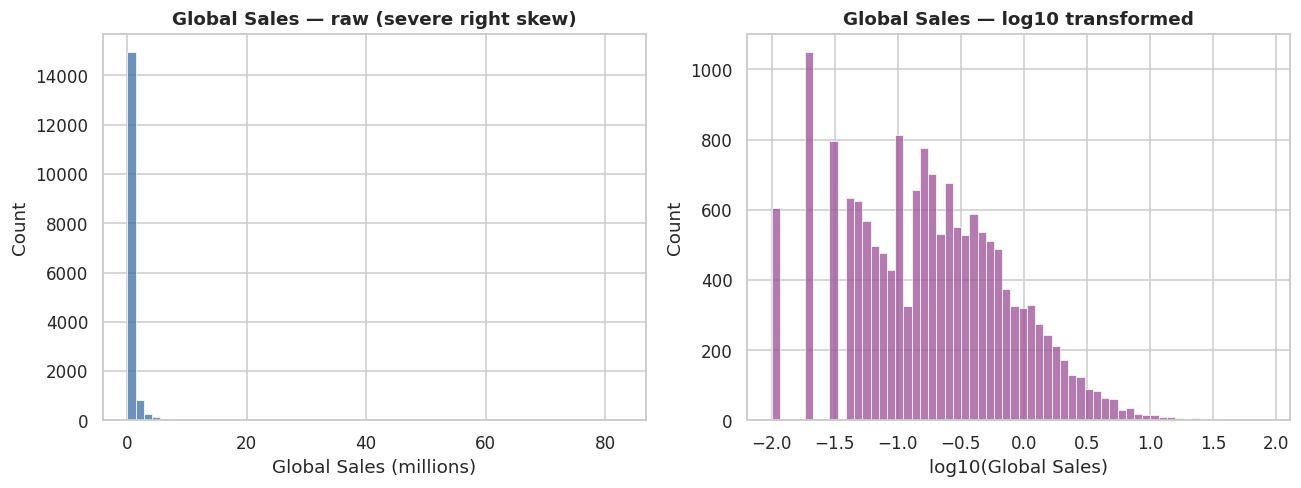

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.histplot(sales, bins=60, color="#3b6ea5", ax=axes[0])
axes[0].set_title("Global Sales — raw (severe right skew)")
axes[0].set_xlabel("Global Sales (millions)")

sns.histplot(np.log10(sales), bins=60, color="#9a4f96", ax=axes[1])
axes[1].set_title("Global Sales — log10 transformed")
axes[1].set_xlabel("log10(Global Sales)")

plt.tight_layout()
plt.show()

Global sales are severely right-skewed (skewness ~ 17) which means that most games sell modestly while a few blockbusters dominate. This is why the mean (~ 0.54M) sits far above the median (~ 0.17M), and why 1827 games (11%) register as statistical outliers under the IQR rule. A log transformation reshapes the data into a roughly bell-shaped distribution.